"""  
아래 내용이 필수적으로 들어가야 합니다.

1. **연관 분석**
    - 연관 분석의 정의
    - 지지도, 신뢰도, 향상도
    - 연관 분석의 알고리즘
        - Apriori 알고리즘
        - FP Growth 알고리즘
2. **경영 기초**
    - 문제 정의와 문제 구조화
    - 지표
        - 북극성 지표, L1/L2 Metrics
        - AARRR
    - 지표 분석 방법
        - 코호트 분석
        - 퍼널 분석

"""

# **연관분석**
## 연관분석이란?
- 정의: 상품이나 서비스를 구매하는 등 **일련의 거래나 사건 안에 존재하는 항목 간**의 연관 규칙을 발견하는 분석 -> 마케팅 전략 수립
- 정답이 따로 없는 비지도학습
- Apriori, FP-Growth 알고리즘
### [연관규칙 분석]
- 형태: **if(조건절) ~ then(결과절)**
- 조건절과 결과절을 구성하는 아이템, 즉 우리가 연결지어 알아보고자 하는 품목들 = 아이템 집합
    - **상호배반**: 같은 항목이 두 절 모두에 들어가면 X. 각 절의 아이템이 겹치면 X
- 연관규칙을 통해 상관관계를 파악하는 것이지, 인과관계를 파악할 수는 없다.
    - 통제된 상황에서 설계된 실험이 아니고, 관찰된 특성이 그렇다는 것일뿐

## 주요 개념
### [연관규칙의 조건]
- **일정 이상의 지지도**: 두 품목 A,B를 함께 구매한 경우의 수가 일정 수준 이상
- **일정 이상의 신뢰도**: 품목 A를 포함하는 거래 중 품목 B를 구입하는 경우의 수가 일정 수준 이상
- 여기에 **향상도**까지 높아야 효과적인 규칙
### [지지도]
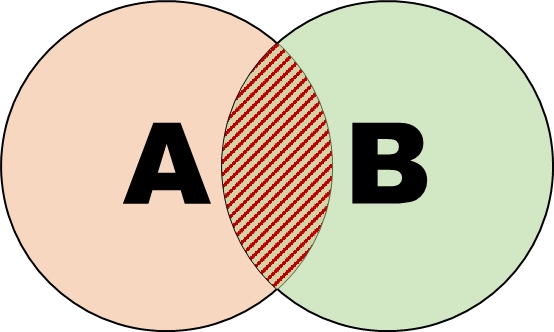  
- **전체 거래 중** A와 B가 동시에 포함되는 거래의 비율 (= $P(A \cap B)$) -> 현실적으로 유의미한지를 판단하는 기준
> 만약 지지도가 낮으면 어떻게 되나요?  

우연일 수 있는 규칙을 포함하거나, 규칙이 충분히 발생하지 않아 현실 적용(마케팅, 추천 등)이 어렵다.
### [신뢰도]
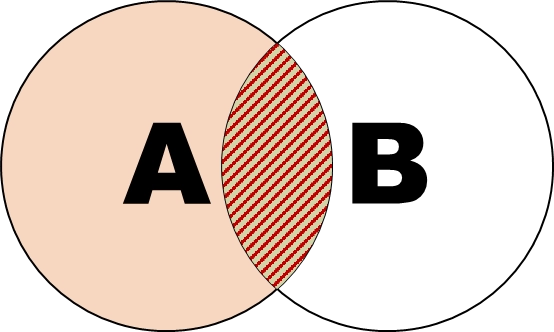  
- **품목 A를 포함하는 거래 중** 품목 A와 B가 동시에 포함되는 거래의 비율 (= $\frac{P(A \cap B)}{P(A)} = \frac{지지도}{P(A)}$) -> 조건부 확률 P(B|A)와 동일
> 만약 신뢰도가 낮으면 어떻게 되나요?  

말그대로 의미 없는 연관 규칙이 되어 추천 실패로 이어진다.  

> 지지도랑 신뢰도랑 둘 다 교집합을 가리키는 거 같은데..  

분자는 둘 다 교집합이지만 분모가 다르다. 지지도는 분모가 전체 거래고 신뢰도는 A 거래이다. 따라서 **지지도는 이 조합(A,B)이 전체에서 얼마나 자주 나오는지**를, **신뢰도는 A가 나왔을 때 B가 따라올 가능성이 얼마나 큰지**를 의미한다.
### [향상도]
- 품목 A가 주어지지 않았을 때의 품목 B의 확률 대비, 품목 A가 주어졌을 때의 품목 B의 확률의 증가 비율 $$ {향상도} = \frac{P(A \cap B)}{P(A)P(B)} = \frac{신뢰도}{P(B)}$$
- A와 B가 함께 등장하는 것이 우연일 때랑 실제일 때를 비교하는 것

| 향상도 | A와 B의 관계 | 해석 |
| --- | --- | --- |
| > 1 | 우연적 확률 < 실제 확률 (두 품목이 서로 **양의 상관관계**) | A 구매가 B 구매로 잘 이어짐 |
| = 1 | **독립** | A 구매와 B 구매 사이에 연관성 X |
| < 1 | 우연적 확률 > 낮은 확률 (두 품목이 서로 **음의 상관관계**) | A를 구매하면 B는 잘 안 삼 |

## 연관분석 알고리즘
### [Apriori 알고리즘]
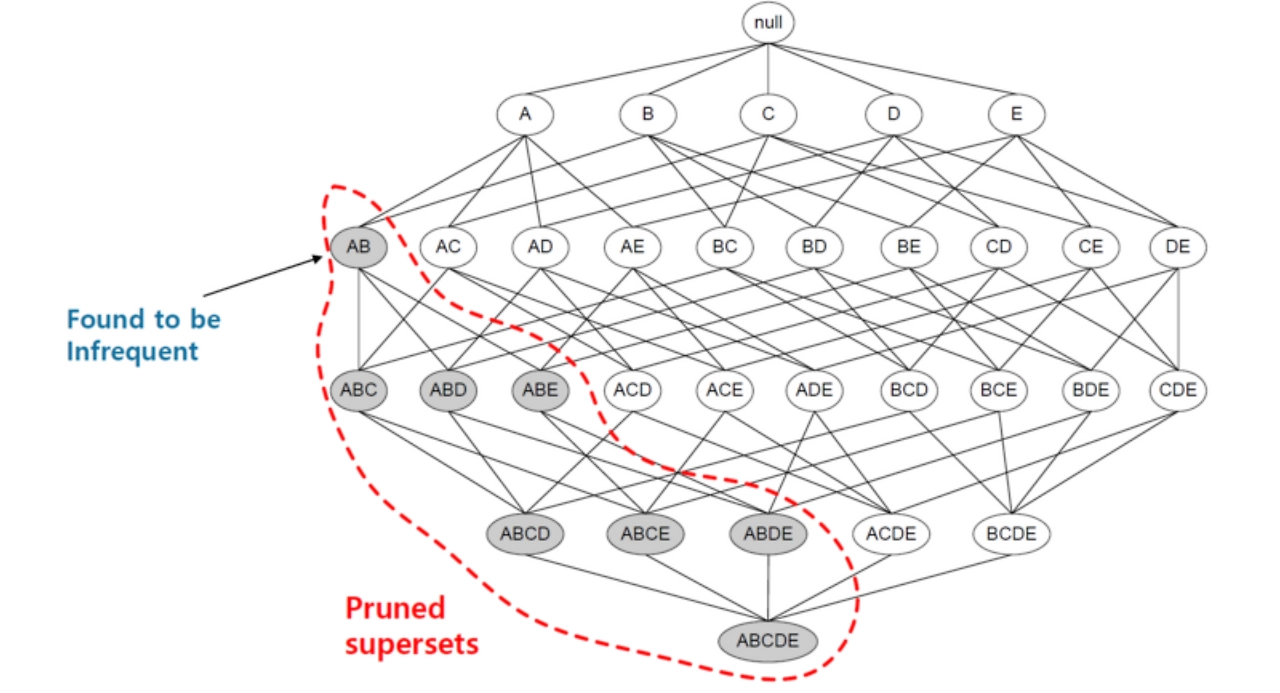  
- Apriori = A Priori -> 즉, 선험적 경험 이용
- 개념: 상위조합부터 차례로 스캔하면서 **발생빈도가 낮은 조합의 결과물로 탄생한 후속조합까지 탐색을 배제**하면서, 가능한 모든 조합을 시도해보는 비효율성을 막기 위한 알고리즘
- 장점
    - **시간, 연산량 ↓** (특정 집합{A,B}의 지도가 사용자가 정한 최소 지지도를 못 넘으면 거기서 파생된 다른 조합 모두 배제 가능)
    - 간단한 원리
- 단점
    - 데이터가 커질수록 속도 ↓
- 프로세스  
    **<일정 최소 지지도를 넘는 항목(빈발 항목)만 남겨두고, 단계적으로 조합 생성이 목적>**
    1. 단일 항목 집합 생성: 모든 개별 상품의 지지도 계산, 최소 지지도 넘는 거만 남기기
    > 지지도는 품목이 최소 두 개는 있어야하지 않나요? 어떻게 단일 항목의 지지도를 구하는 거지..  

    지지도 = 전체 거래 중 A와 B가 동시에 포함되는 거래의 비율 -> 이걸 일반화하면 **지지도 = 전체 거래 중 A를 포함하는 거래의 비율**

    2. 2개 항목 집합 생성: 남은 상품으로 2개 항목 조합 생성 및 지지도 계산, 최소 지지도 넘는 거만 남기기
    3. 3개 이상의 항목 집합 생성: 남은 상품으로 3개 이상의 항목 조합 생성 및 지지도 계산, 최소 지지도 넘는 거만 남기기 -> 더이상 조합 생성이 불가할 때까지 반복
    4. 최종 빈발 항목 집합 생성: 남은 항목 집합을 바탕으로 연관규칙 생성. 가장 유용한 규칙 선택(<-지지도, 신뢰도, 향상도)
### [FP Growth 알고리즘]
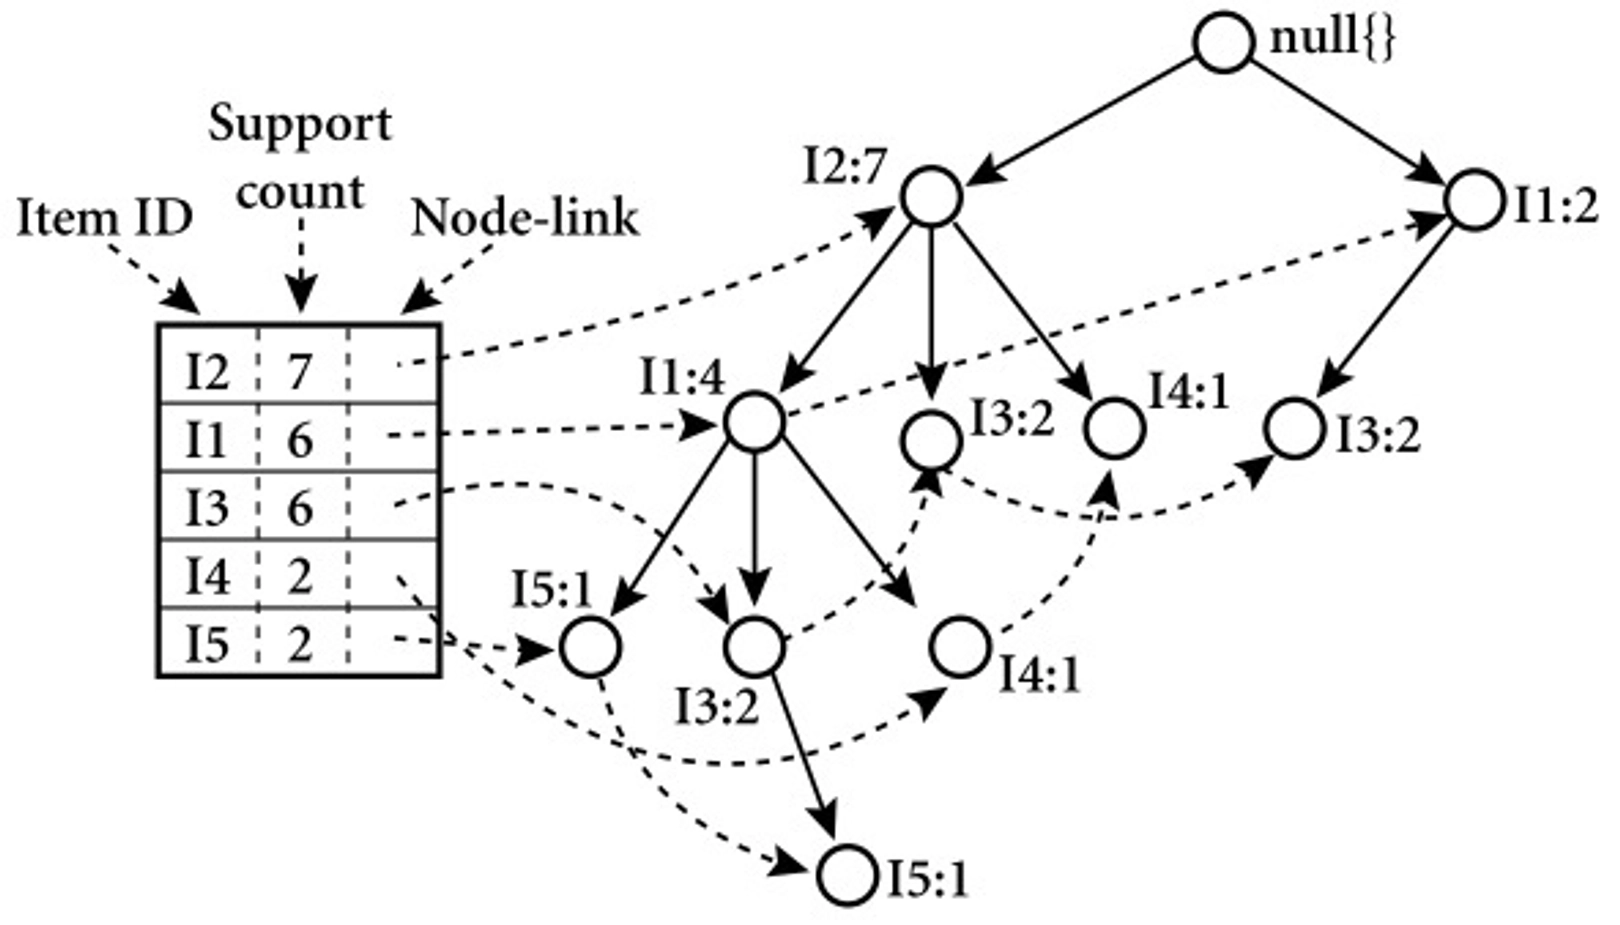  
- FP-Tree 구조(Tree + Array + Linked_List)를 이용하여 Apriori를 효과적으로 구현
    - 그림에서 null{}부터 시작되는 게 트리: 다른 아이템끼리는 부모자식 관계
    - 왼쪽이 array: item ID와 지지도를 빈도가 높은 순서로 저장
    - **링크(점선)를 통해 같은 아이템 노드를 연결**하고 있음 -> 이걸 따라가면 **특정 아이템이 들어 있는 모든 경로**를 빠르게 따라갈 수 O
    - 각 노드에 적힌 숫자는 (item ID : 지지도) -> **아래로 가면서** 해석이 이어짐(= **조건에 맞는 아이템의 개수 파악 가능**)  
    ex) null{} -> A(12:7), B(11:2) : 전체 데이터(9개)에서 A가 처음으로 등장하는 셋(7개)과 B가 처음으로 등장하는 셋(2개. 이건 A를 포함 X)으로 나눔  
    A(12:7) -> C(11:4) : A가 처음으로 등장하는 셋 중에 다음으로 C가 등장하는 셋의 개수가 4
- 트리는 모든 거래에 대해 반복하고, 최소 지지도 이상의 패턴을 추출
- 장점
    - 데이터를 두 번만 스캔 ->Apriori보다 빠름
    - 후보 itemset 생성 X
    > 후보 아이템셋이란?  

    지지도를 계산하기 전에 만든 조합. 각 후보 itemset에 대해 지지도를 계산하고, 기준을 통과한 itemset이 빈발 itemset이 됨
    
- 프로세스
    1. 데이터셋 확인: 어떤 품목을 몇 명이 샀는가?
    2. 빈도순 재정렬: 각 거래별로 빈도순 정렬 -> f-list(array) 생성
    3. FP-트리 생성: 0 노드를 시작으로, 빈도가 높은 item부터 노드 추가
        - 자식 노드를 추가할 때마다 자식 노드와 조상 노드에 1씩 더함
        - 이 숫자는 특정 경로에서 해당 품목의 개수가 됨
    4. 빈발 항목 집합 추출: 특정항목을 기준으로 부분 트리를 만들어 빈발 항목 집합 추출 -> 기준 항목과 연관된 빈발 항목 집합 추출
    > 어떻게 하는 거지

    - 특정 품목 선택
    - 그 품목이 나타나는 위치를 전부 찾고, 각 위치에서 조상 노드를 따라 올라감
    - 각 품목별로 조상 경로에서 나온 개수를 합함
    - 최소 지지도를 넘은 itemset에 버터를 포함시킨 게 빈발항목 집합

    5. 연관 규칙 도출: 각 규칙에 대해 지지도, 신뢰도, 향상도 계산해서 가장 유용한 규칙 선택


# **경영 기초**
## 문제 정의와 구조화
### [문제 정의]
- **문제 = 현재의 상태와 바라는 상태 사이의 격차**. 어떤 상황을 **해결해야할 구체적인 질문**으로 전환한 것
- SMART 원칙->좋은 목표 설정
    | **SMART 원칙** | **특징** | **의미** |
    | --- | --- | --- |
    | **S**pecific | 구체적이고 범위가 명확함 | 무엇을, 어디까지 풀지 명확하게 정의 |
    | **M**easurable | 수치로 측정 가능함 | 성공 여부를 숫자로 판단 가능 |
    | **A**ction-oriented | 실행 지향적 / 결과 중심적 | 행동을 이끌어내고 성과에 집중함 |
    | **R**elevant | 관련성 | 조직의 목표와 관련이 있어야 함 |
    | **T**ime-bound | 시한성 (Time-bound) | 마감 기한과 의사결정 시점이 존재함 |
### [문제 구조화]
- MECE: Mutually Exclusive(상호 배타적-중복 방지), Collectively Exhaustive(전체 포괄적-누락 방지)  
    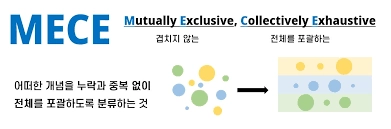
    - 좋은 MECE를 하려면: 논리적 일관성(하나의 기준으로 나눔), 통찰력(도움이 되는 기준), 상호배타성(중복 X)

## 지표
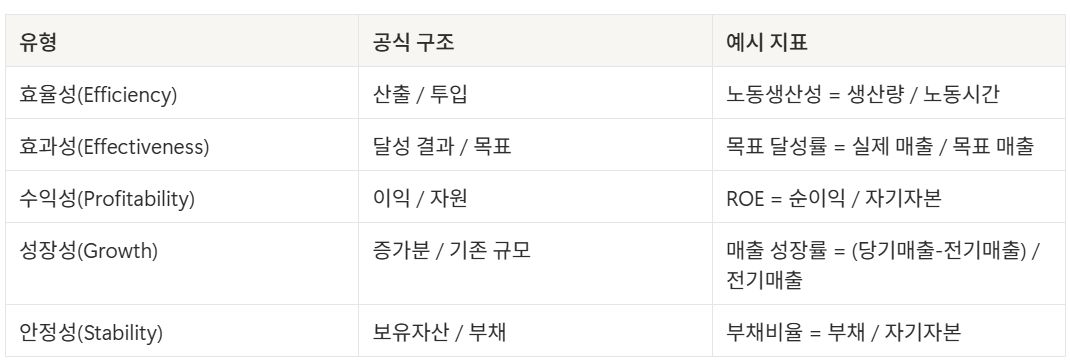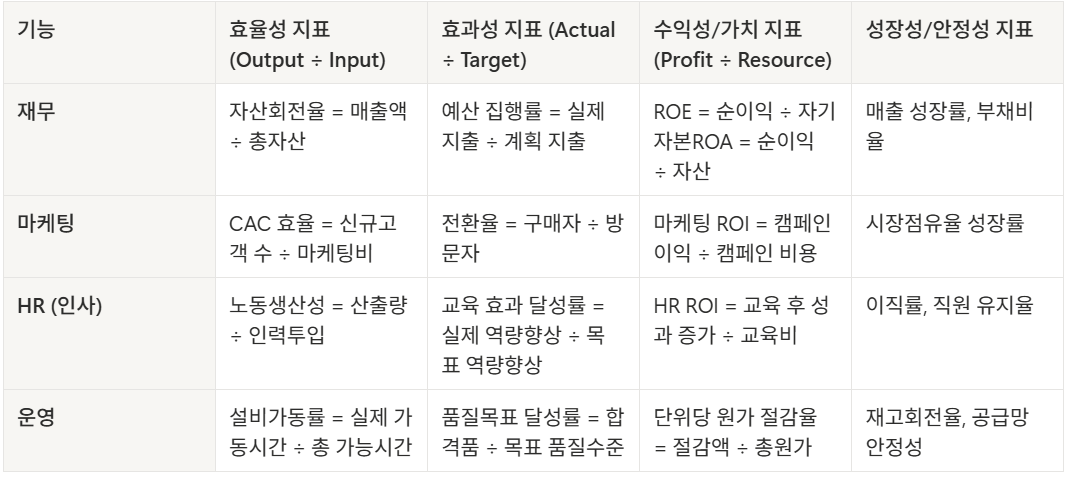
- 개념: 방향이나 목적, 기준 등을 나타내는 표지. 측정하고 싶은 것을 숫자로 표현한 것
    > 만약 지표의 분자, 분모에 들어갈 절대적인 수치를 구할 수 없다면?  

    => **Proxy Metric** 설정: 추상적이어서 프로덕트마다 나름의 가정과 정의, 논의가 필요한 지표(ex: 활성화). 정답 X
    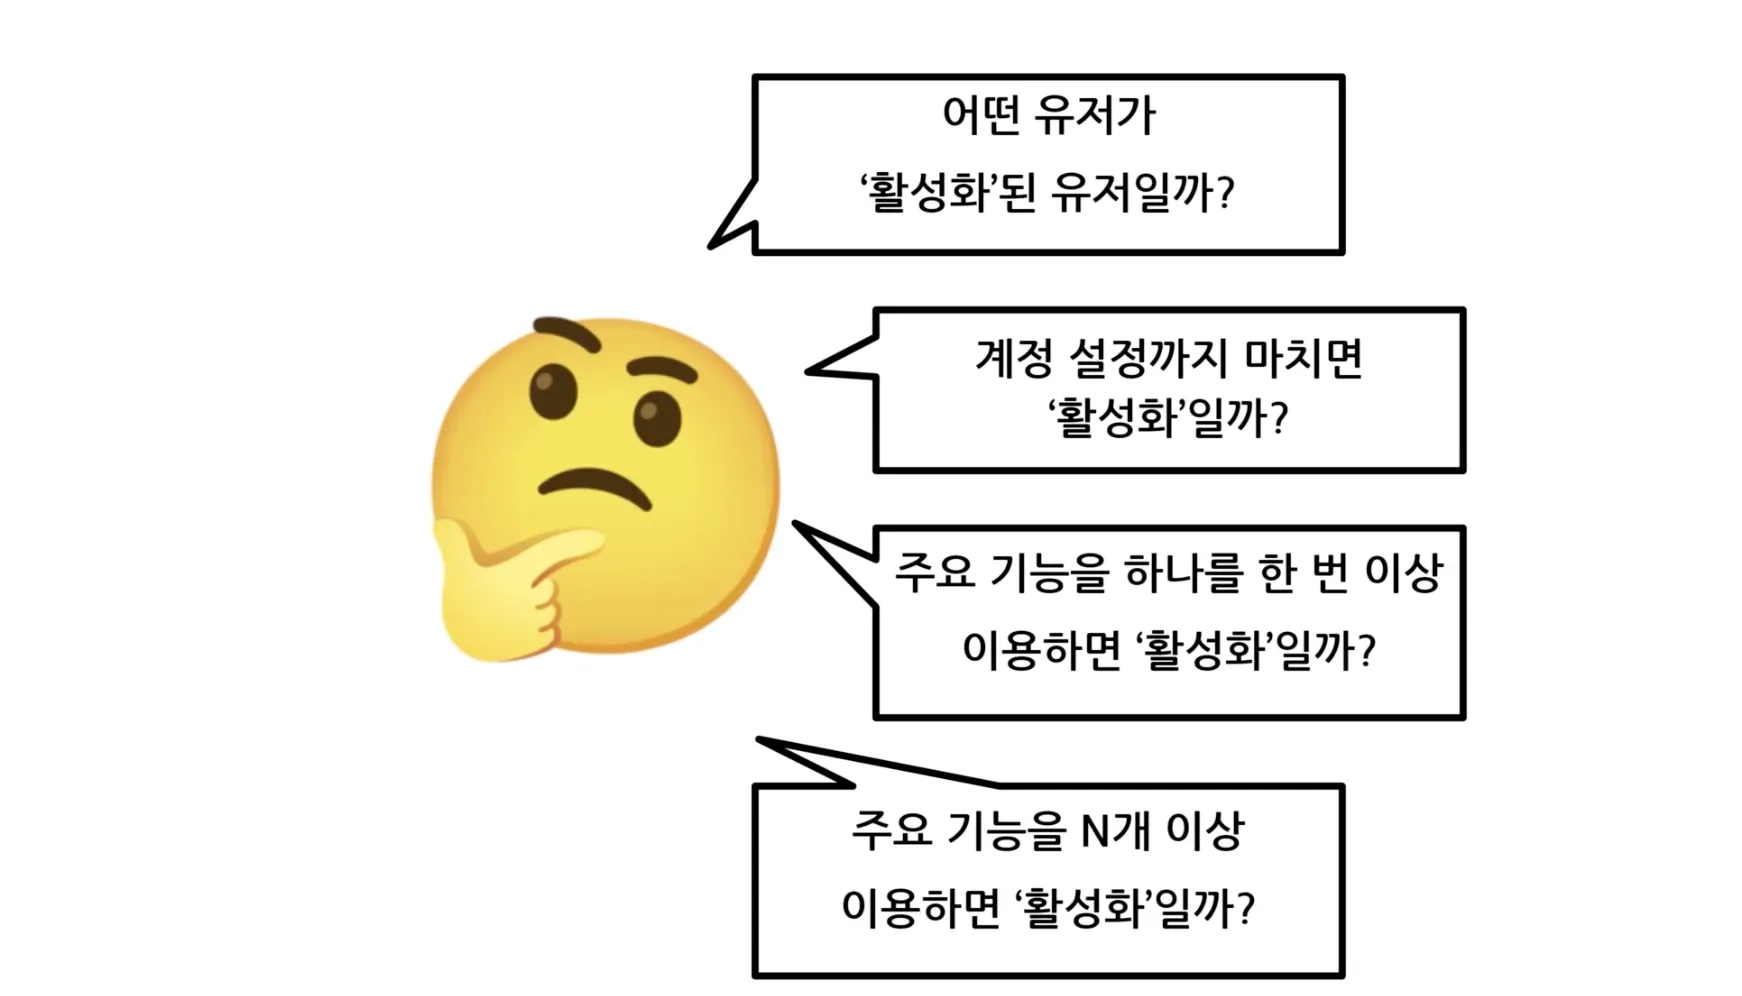
### [북극성 지표, L1/L2 Metrics]
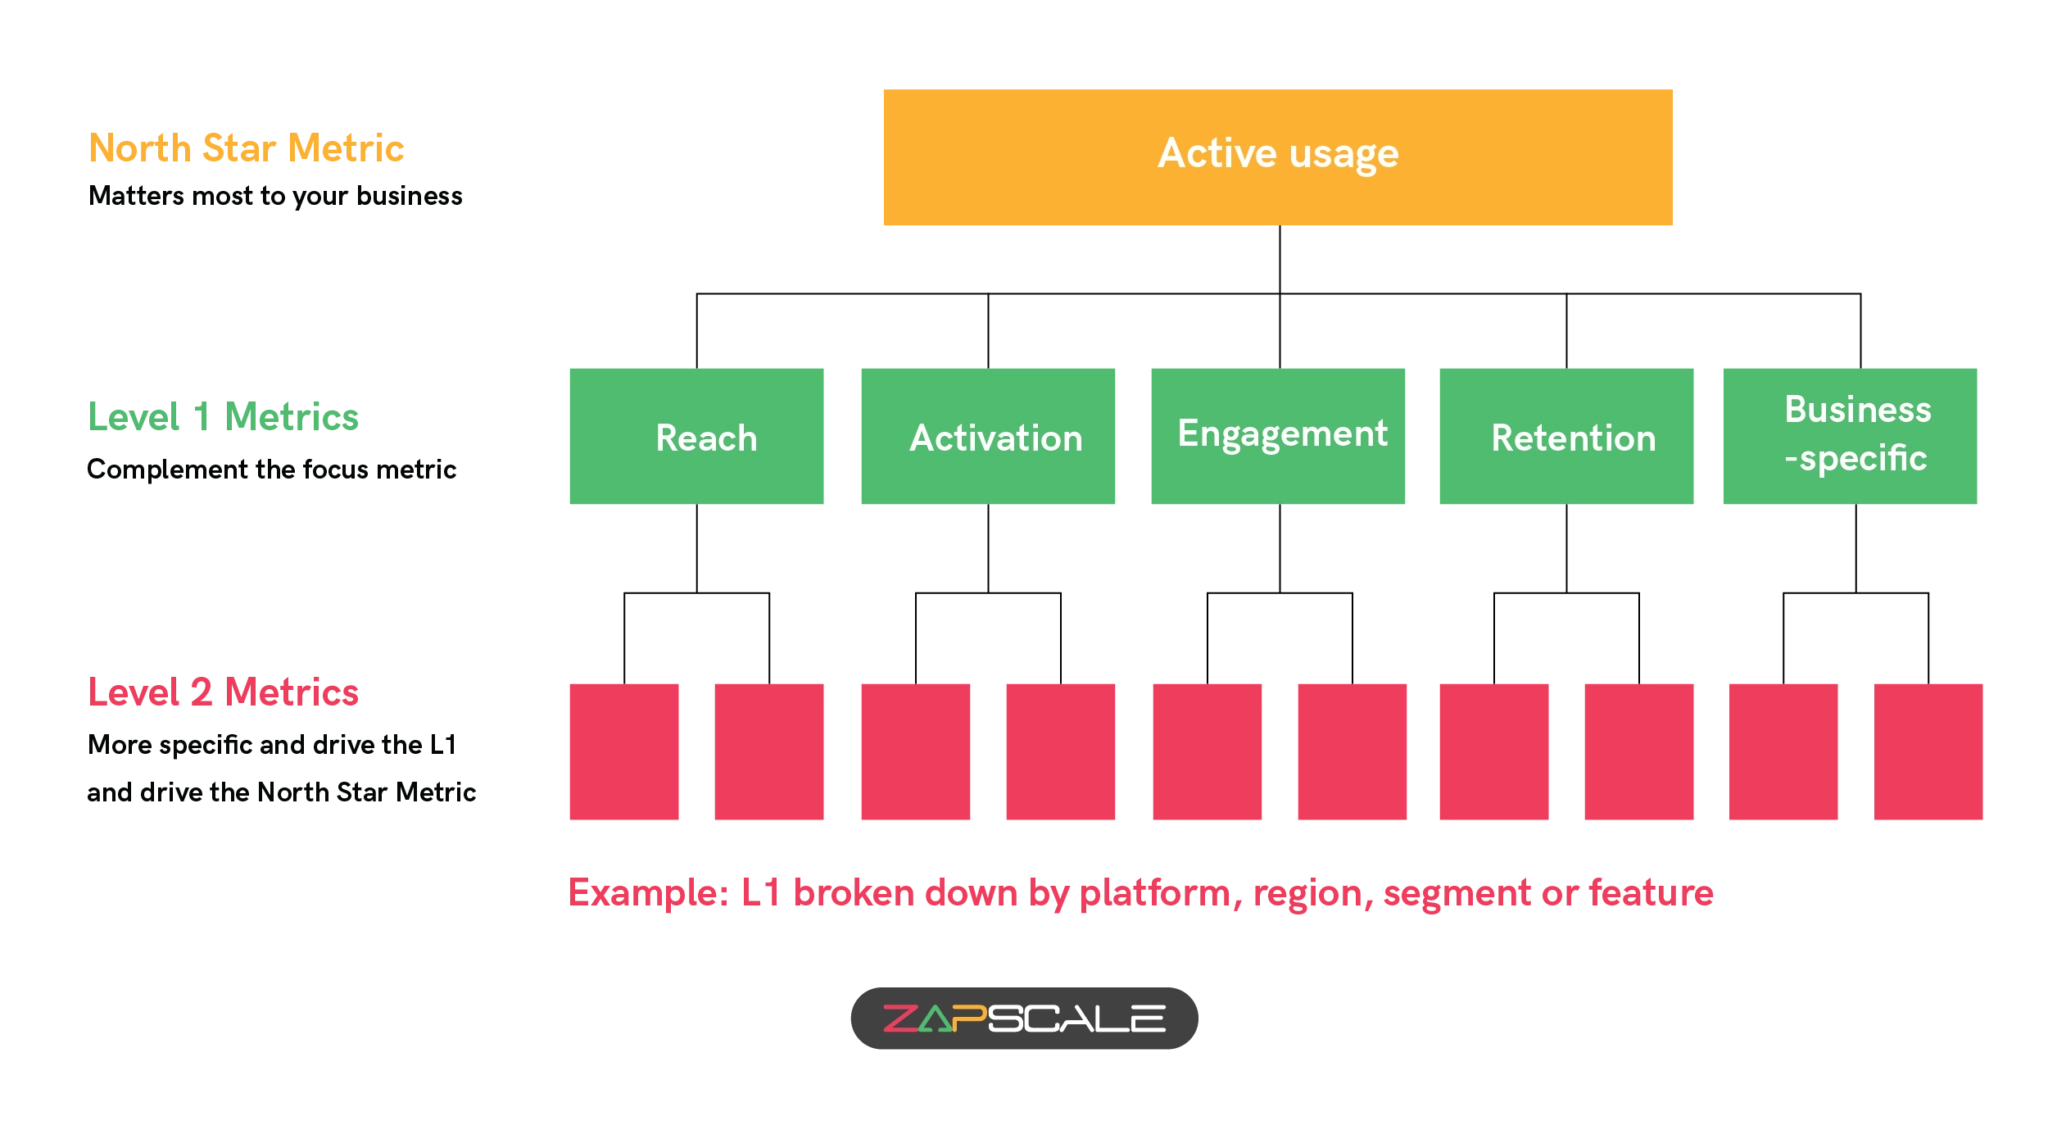  
- **북극성 지표**: 기업이 가장 중요하게 생각하는 지표
- **L1** 지표: 전략 관점에서 **전사적**인, **고수준**의 성과 지표
- **L2** 지표: 전술 관점에서 **L1 지표의 세부 사항**을 측정하는 지표
> KPI란?  
Key Performance Indicator의 약자로, 핵심성과지표를 의미한다. 성공의 의미를 구체적으로 정의하고 우선순위를 파악함으로써 기업이 나아갈 방향을 끊임없이 조정한다.

> OKR이란?
도전적인 목표, 즉 **궁극적인 목표**(Objective)를 설정하고 / 핵심결과, 즉 목표 달성 여부를 판단하는 **구체적이고 정량화된 결과 지표**(Key Result)를 도출한다.

### [AARRR(해적 지표)]
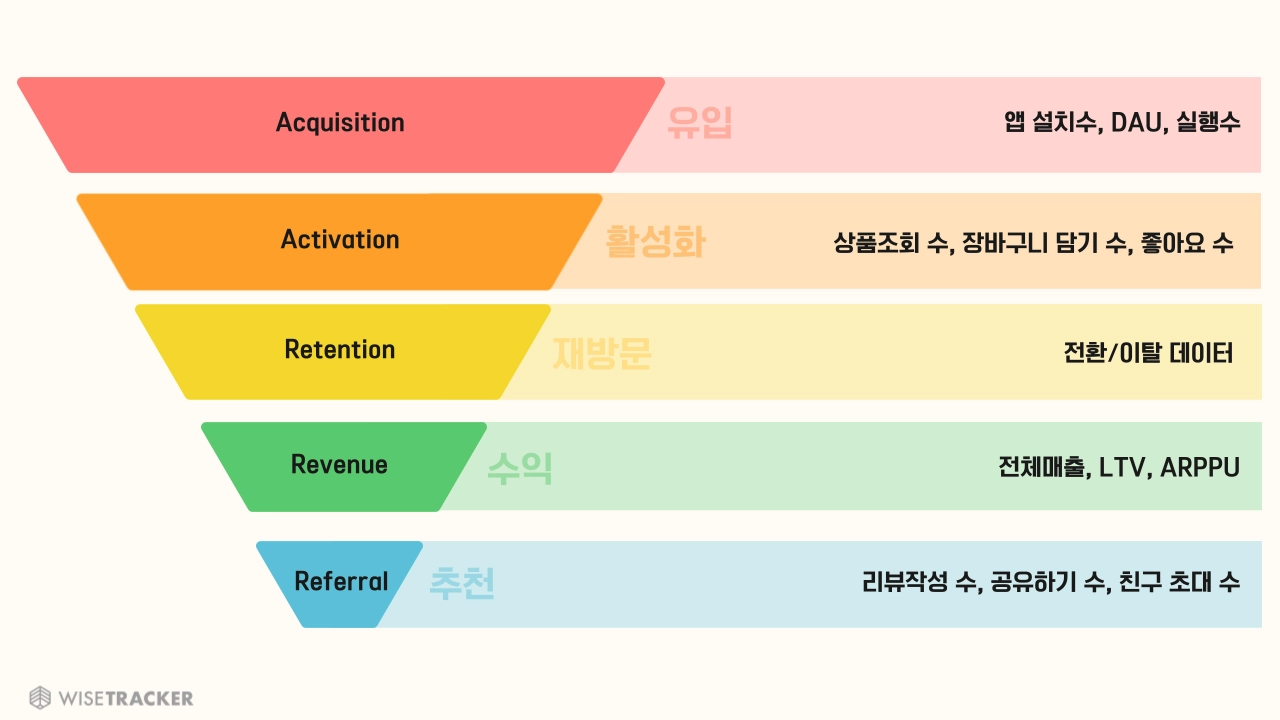  
- 개념: 사용자 증가를 위한 5가지 로드맵. 프로덕트가 가치를 제공하는 방식에 따라 달라짐
- **A**quisition(획득): 사용자가 여러 채널을 통해 **앱 혹은 웹사이트에 방문**하는 것. 어떤 제품이냐에 따라 측정 기준 상이
    - "**신규 고객을 어디서 어떻게 획득할 것인가**?"    ex) 광고, 검색엔진, 지인 등
    - 대체로 조회수, 가입 사용자 수 등의 지표로 측정
- **A**ctivation(활성화): 사용자가 앱 또는 웹사이트에 첫 방문하여 **주요 기능을 직접 사용**하는 것. 제품의 성격에 따라 측정 기준 상이  
    <단계>
    1. Sign-up: 유저가 제품에 들어온 시점
    2. Setup Moment: 유저가 제품의 핵심가치를 경험할 준비 완료
    3. A-HA! Moment: 유저가 핵심가치를 처음 경험한 순간
    4. Habit Moment: 유저가 제품 사용에 대한 습관 형성  

- **R**etention(유지): 신규 사용자를 장기 사용자로 전환시키는 것
    - "**어떻게 장기 고객을 양성할 것인가**?", "**어떻게 고객의 지속적인 구매를 증사시킬 것인가**?"
    - 익일 유지율, 1주차 유지율, 2주차 유지율, 월 유지율, EDM 메일 개설율 등의 지표 사용
- **R**evenue(수익): 사용자가 제품 혹은 서비스를 유료 구매하기로 결정한 단계. 제품 성격에 따라 측정 기준 상이
    - "**어떻게 하면 사용자의 소비를 유도할 수 있을까**?"
    - 고객의 평생 가치(LTV)를 높이고, 고객 유치비용은 줄여야함
    > LTV: 한 고객이 특정 서비스를 이용하는 전체 기간동안 기업에 가져다주는 가치의 양
- **R**eferral(추천): 사용자가 타인에게 서비스를 추천하는 단계
    - "어떻게 충성도 높은 사용자를 보이지 않는 브랜드 홍보자로 만들 것인가?", "**어떻게 제품을 잠재 고객들에게 추천하도록 만들 것인가**?"
    - 순 추천고객 지수(=브랜드에 대한 사용자의 만족도), 바이럴 지수(=사용자가 평균적으로 추천하는 고객의 수)가 대표적인 지표

## 지표 분석 방법
### [코호트 분석]
- 코호트: 동질 집단 -> **정의된 시간 범위 내**에서 **공통된 특성이나 경험**을 공유하는 사용자 집단 (기간 + 특성)
- 코호트 분석: 데이터를 관련 그룹으로 나누어 분석하는 것
- 주로 **사용자 유지와 이탈을 체크**하는 데 사용
- 해석 방법
    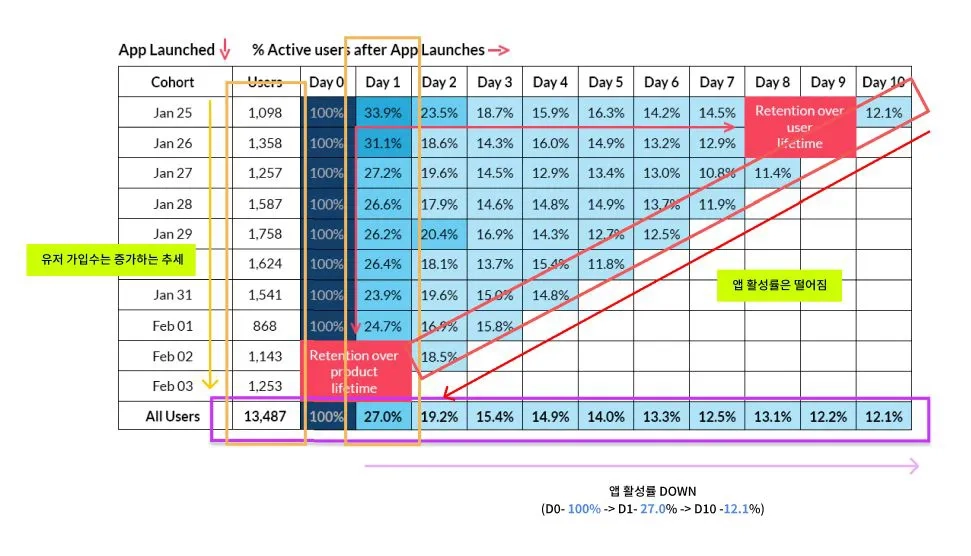  
    - 세로축: 코호트별 비교. 같은 기간이 지난 후 코호트 간 리텐션 비교
    - 대각선: 시점별 비교
    - 가로축: 시간의 경과에 따른 변화 관찰
### [퍼널 분석]
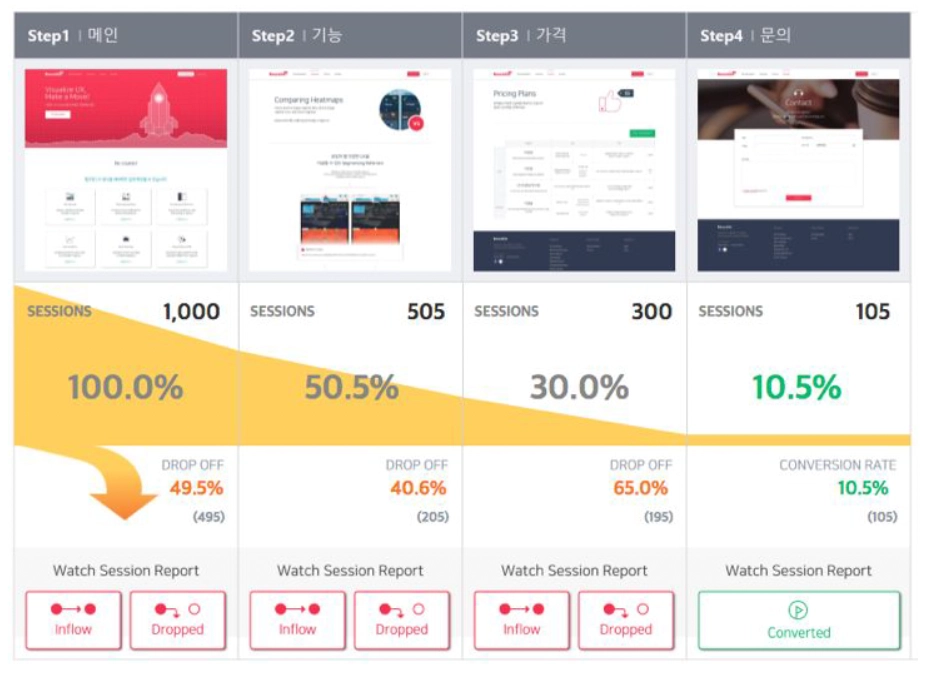

- **유저가 접속해서 떠날 때까지의 유저의 행동 추적**
- 시간이 지날수록 유저가 이탈하므로 아래로 갈수록 좁아지는 형태
### [개선 방법 예시]
1. 유입률(Acquisition) 높이기
2. 전환율(Activation) 높이기
3. 퍼널 단계 없애기
4. 퍼널 순서 바꾸기
5. 퍼널 단계 추가하기
6. 코호트로 나누어 보기